## Prototype B-Cos Train & Interpret pipeline

This is a prototype for training and interpreting a B-Cos resnet model on the audio-speech dataset from the RAVDESS database. RAVDESS makes for a simple prototyping case because every audio-speech fragment is exactly 3 seconds long, and therefore easily convertable to one spectrogram each.

The model is trained on Log Mel Spectrograms using the ResNet18 architecture. The general pipeline for generating the explanation of an audio-speech file is as follows - but should later be further extended (with invertible lossless transformations) for more accurate classification results:

*.wav file &rarr; STFT spectrogram &rarr; Log Mel spectrogram &rarr; Mel explanation (B-Cos model explanation) &rarr; mask in STFT space (approx. since lossy) &rarr; masked STFT spectrogram &rarr; masked .wav file*

### 0. Initialization

Imports & Config variables

In [2]:
import os
import torch
import torchaudio
import torchmetrics
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import soundfile as sf

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint, TQDMProgressBar
from pytorch_lightning.loggers import CSVLogger
from IPython.display import Audio
from functools import partial

from bcos.models.resnet import resnet18
from bcos.modules.bcosconv2d import BcosConv2d
from bcos.optim import OptimizerFactory, LRSchedulerFactory
from bcos.modules.losses import BinaryCrossEntropyLoss
from bcos.data.transforms import AddInverse

torch.set_float32_matmul_precision("medium") # or "high", tradeoff between speed and precision

In [3]:
# ----------------------------
# AUDIO + FEATURE PARAMETERS
# ----------------------------

SR = 48000  
# Sample rate (Hz)
# = number of audio samples per second

DURATION = 3  
# Fixed audio clip length in seconds
# Each training sample will be cropped/padded to this duration

NUM_SAMPLES = SR * DURATION  
# Total number of waveform samples per training example
# Example: 48000 * 3 = 144000 samples per audio clip

# ----------------------------
# STFT (SPECTROGRAM SETTINGS)
# ----------------------------

N_FFT = 1024  
# FFT window size (how many samples are analyzed at once)
# Controls frequency resolution:
#   larger → better frequency detail, worse time precision
#   smaller → better time precision, worse frequency detail
# At 48kHz: ~64ms analysis window

HOP = 256  
# Step size between consecutive FFT windows
# Controls time resolution of spectrogram
# At 48kHz: ~16ms shift per frame
# Smaller hop → smoother time axis, larger compute cost

# ----------------------------
# MEL SPECTROGRAM SETTINGS
# ----------------------------

N_MELS = 80  
# Number of mel frequency bands
# Compresses STFT frequencies into perceptual scale
# Instead of ~513 STFT bins → 80 mel bands
# Used as CNN input channels (frequency axis)

### 1. Pipeline Transformation Components

Transformation to Log Mel Spectrogram

In [4]:
mel_transform = torchaudio.transforms.MelSpectrogram( # computes STFT internally
    sample_rate=SR,
    n_fft=N_FFT,
    hop_length=HOP,
    n_mels=N_MELS
)
to_db = torchaudio.transforms.AmplitudeToDB() # linear mel → log mel conversion

STFT transformation & inverse STFT transformation

In [5]:
class STFT:
    def __init__(self):
        self.window = torch.hann_window(N_FFT)

    def forward(self, wav):
        return torch.stft(
            wav,
            n_fft=N_FFT,
            hop_length=HOP,
            window=self.window,
            return_complex=True
        )

    def inverse(self, spec):
        return torch.istft(
            spec,
            n_fft=N_FFT,
            hop_length=HOP,
            window=self.window
        )

Transformation from Log Mel spectrogram to STFT spectrogram

In [6]:
def mel_to_stft(explanation, stft_spec):
    return F.interpolate(
        input=torch.from_numpy(explanation).squeeze(-1).unsqueeze(0).unsqueeze(0), # (1, 1, n_mels, time)
        size=stft_spec.shape,
        mode="bilinear",
        align_corners=False
    )

### 2. Load RAVDESS dataset

**Filename identifiers **

- Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
- Vocal channel (01 = speech, 02 = song).
- Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
- Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
- Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
- Repetition (01 = 1st repetition, 02 = 2nd repetition).
- Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

In [ ]:
EMOTION_MAP = {
    "01": 0, "02": 1, "03": 2, "04": 3,
    "05": 4, "06": 5, "07": 6, "08": 7
}

INTERPRETABILITY_MAP = {
    0: "neutral", 1: "calm", 2: "happy", 3: "sad",
    4: "angry", 5: "fearful", 6: "disgusted", 7: "surprised"
}

class RAVDESSCachedBuilder:
    def __init__(self, root, cache_dir, actors):
        self.root = root
        self.cache_dir = cache_dir
        self.actors = actors

        os.makedirs(cache_dir, exist_ok=True)

    def process(self):
        for r, _, files in os.walk(self.root):
            for f in files:
                if not f.endswith(".wav"):
                    continue

                parts = f.split("-")
                if len(parts) < 7:
                    continue

                actor = int(parts[-1].split(".")[0])
                if actor not in self.actors:
                    continue

                emotion = parts[2]
                if emotion not in EMOTION_MAP:
                    continue

                path = os.path.join(r, f)

                cache_path = os.path.join(self.cache_dir, f.replace(".wav", ".pt"))

                if os.path.exists(cache_path):
                    continue

                #wav, sr = torchaudio.load(path) # causes torchcodec loaderror...

                wav, sr = sf.read(path, dtype="float32")
                wav = torch.from_numpy(wav)

                if wav.ndim == 1:
                    wav = wav.unsqueeze(0)
                else:
                    wav = wav.T

                # Resample
                if sr != SR:
                    wav = torchaudio.functional.resample(wav, sr, SR)

                # Convert stereo to mono
                wav = wav.mean(dim=0, keepdim=True)

                # pad/crop
                if wav.shape[1] > NUM_SAMPLES:
                    wav = wav[:, :NUM_SAMPLES]
                else:
                    wav = F.pad(wav, (0, NUM_SAMPLES - wav.shape[1]))

                # feature extraction
                x = mel_transform(wav)
                x = to_db(x)

                y = EMOTION_MAP[emotion]

                torch.save((x.cpu(), torch.tensor(y)), cache_path)

In [8]:
class RAVDESSCached(Dataset):
    def __init__(self, cache_dir):
        self.files = [
            os.path.join(cache_dir, f)
            for f in os.listdir(cache_dir)
            if f.endswith(".pt")
        ]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        try:
            x, y = torch.load(self.files[idx], map_location="cpu")
            return x, y
        
        except Exception as e:
            print("FAILED FILE:", self.files[idx])
            raise e

        x, y = torch.load(self.files[idx])
        return x, y

In [9]:
train_actors = list(range(1, 22))
test_actors = list(range(22, 25))

RAVDESSCachedBuilder("Audio_Speech_Actors_01-24", "cache/train", train_actors).process()
RAVDESSCachedBuilder("Audio_Speech_Actors_01-24", "cache/test", test_actors).process()

train_set = RAVDESSCached("cache/train")
test_set = RAVDESSCached("cache/test")

# train_set = RAVDESS("Audio_Speech_Actors_01-24", train_actors)
# test_set = RAVDESS("Audio_Speech_Actors_01-24", test_actors)

# train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=2, persistent_workers=True, pin_memory=True)
# test_loader = DataLoader(test_set, batch_size=16, num_workers=2, persistent_workers=True, pin_memory=True)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=16, num_workers=0, pin_memory=True)

print(f"Train samples: {len(train_set)}, Test samples: {len(test_set)}")

Train samples: 1260, Test samples: 240


### 3. Train Model

Trains a resnet18 B-Cos model on the dataset. Only run the last cell if you want to train a new model, but beware of runtimes, as 50 epochs already took ~40 mins on a 9070 XT.

In [10]:
class SentimentModel(pl.LightningModule):
    def __init__(self, config: dict, model: nn.Module, num_classes: int):
        super().__init__()
        self.config = config
        self.model = model
        self.criterion = config["criterion"]
        self.test_criterion = config["test_criterion"]
        self.train_acc = torchmetrics.Accuracy(
            task="multiclass", num_classes=num_classes, top_k=1
        )
        self.val_acc = torchmetrics.Accuracy(
            task="multiclass", num_classes=num_classes, top_k=1
        )

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.train_acc(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", self.train_acc, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.test_criterion(logits, y)
        self.val_acc(logits, y)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_acc, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        opt = self.config["optimizer"].create(self.model)
        sched = self.config["lr_scheduler"].create(
            opt, total_steps=self.trainer.estimated_stepping_batches
        )
        return dict(optimizer=opt, lr_scheduler=sched)

In [11]:
def train_bcos(
    model: nn.Module,
    config: dict,
    num_classes: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    save_dir: str = "./experiments",
    experiment_name: str = "experiment",
    max_epochs: int = 50,
    accelerator: str = "auto",
    devices: str = "auto",
    seed: int = 42,
):
    pl.seed_everything(seed, workers=True)

    save_path = Path(save_dir, experiment_name)
    save_path.mkdir(parents=True, exist_ok=True)

    sentiment_model = SentimentModel(config, model, num_classes)

    trainer = pl.Trainer(
        default_root_dir=save_path,
        max_epochs=max_epochs,
        accelerator=accelerator,
        devices=devices,
        callbacks=[
            ModelCheckpoint(
                dirpath=save_path,
                monitor="val_acc",
                mode="max",
                filename="{epoch}-{val_acc:.4f}",
                save_last=True,
                save_top_k=3,
            ),
            TQDMProgressBar(refresh_rate=5),
        ],
        logger=CSVLogger(save_dir=str(save_path / "logs")),
        num_sanity_val_steps=0,
    )

    trainer.fit(sentiment_model, train_loader, val_loader)


In [11]:
model = resnet18(
    num_classes=8, 
    in_chans=1, 
    small_inputs=True,
    conv_layer=partial(BcosConv2d, b=2, max_out=2)
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config = {
        "criterion": BinaryCrossEntropyLoss(),
        "test_criterion": BinaryCrossEntropyLoss(),
        "optimizer": OptimizerFactory(name="Adam", lr=1e-4),
        "lr_scheduler": LRSchedulerFactory(name="cosineannealinglr", epochs=10),
    }

train_bcos(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    config=config,
    num_classes=8,
    accelerator="gpu"
)


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\jhofm\Desktop\woofsandmeows\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\jhofm\Desktop\woofsandmeows\experiments\experiment exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.
c:\Users\jhofm\Desktop\woofsandmeows\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

  | Name           | T

Epoch 49: 100%|██████████| 79/79 [00:45<00:00,  1.74it/s, v_num=0, train_loss=0.0114, train_acc_step=1.000, val_loss=0.334, val_acc=0.554, train_acc_epoch=1.000] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 79/79 [00:45<00:00,  1.74it/s, v_num=0, train_loss=0.0114, train_acc_step=1.000, val_loss=0.334, val_acc=0.554, train_acc_epoch=1.000]


### 3.5 Load Model

Change path for different experiments/models. Run this if you only want to load an already existing model from a checkpoint.

In [13]:
model = resnet18(
    num_classes=8, 
    in_chans=1, 
    small_inputs=True,
    conv_layer=partial(BcosConv2d, b=2, max_out=2)
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ckpt = torch.load(os.path.join("experiments", "experiment", "last.ckpt"), map_location=device, weights_only=False)
state_dict = {
        k.removeprefix("model."): v
        for k, v in ckpt["state_dict"].items()
        if k.startswith("model.")
    }
model.load_state_dict(state_dict)

<All keys matched successfully>

### 4. Explanation Audio Fragments

Uses ~ *.wav file &rarr; STFT spectrogram &rarr; Log Mel spectrogram &rarr; Mel explanation (B-Cos model explanation) &rarr; mask in STFT space (approx. since lossy) &rarr; masked STFT spectrogram &rarr; masked .wav file* ~ pipeline to return a masked .wav based on the B-Cos explanation of the classification.

In [14]:
def apply_explanation(explanation, wav):
    stft = STFT()
    stft_spec = stft.forward(wav).squeeze(0)

    mask = mel_to_stft(explanation["explanation"], stft_spec)
    mask = mask.squeeze(0).squeeze(0)
    
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8) # normalize to [0, 1]
    mask = mask ** 2.5 # sharpen the mask to make important regions more distinct
    # mask = torch.exp(mask) - 1
    # mask = mask / mask.max()

    mag = stft_spec.abs() # strength of each time-frequency bin

    threshold = torch.quantile(mask, 0.85)
    binary_mask = (mask >= threshold).float()
    mag_weighted = mag * binary_mask # only keep the top % most important bins according to the explanation
    #mag_weighted = mag * (mask > mask.mean()).float()
    
    phase = stft_spec.angle() # where in the waveform cycle each bin is (important for reconstructing the audio)
    alpha = 3 # Adjust this to control the strength of the explanation

    mag_masked = mag_weighted * (1.0 + alpha * mask)
    spec_masked = mag_masked * torch.exp(1j * phase)

    #spec_masked = stft_spec * mask
    wav_out = stft.inverse(spec_masked.unsqueeze(0))

    print(f"Mask stats - Min: {mask.min()}, Max: {mask.max()}, Mean: {mask.mean()}")
    print(f"Mean absolute difference: {(mag_masked - mag).abs().mean()}")

    return wav_out

In [15]:

def explain_audio(model, path):
    model.eval()
    device = next(model.parameters()).device

    parts = path.split("-")
    emotion = parts[-5]
    #print(f"Emotion: {emotion} ({EMOTION_MAP[emotion]})")
    # y = torch.tensor(EMOTION_MAP[emotion]).unsqueeze(0).to(device)

    #wav, sr = torchaudio.load(path)

    wav, sr = sf.read(path, dtype="float32")
    wav = torch.from_numpy(wav)

    if wav.ndim == 1:
        wav = wav.unsqueeze(0)
    else:
        wav = wav.T

    # Resample to model SR
    if sr != SR:
         wav = torchaudio.functional.resample(wav, sr, SR)
    # Convert stereo -> mono
    wav = wav.mean(dim=0, keepdim=True)
    # Pad/crop to fixed length
    if wav.shape[1] > NUM_SAMPLES:
        wav = wav[:, :NUM_SAMPLES]
    else:
        wav = F.pad(wav, (0, NUM_SAMPLES - wav.shape[1]))

    # stft = STFT()
    # stft_spec = stft.forward(wav).squeeze(0)
    x = to_db(mel_transform(wav)).unsqueeze(1).to(device)

    #explanation = get_attribution(model, x, y)
    explanation = model.explain(x)

    # print(f"Explanation shape: {torch.from_numpy(explanation['explanation']).squeeze(-1).unsqueeze(0).unsqueeze(0).shape}")
    # print(f"STFT spec shape: {stft_spec.shape}")

    # plt.imshow(x.squeeze(0).squeeze(0).cpu().detach().numpy(), aspect="auto", origin="lower")
    # plt.show()

    # plt.imshow(explanation["explanation"].squeeze(), aspect="auto", origin="lower")
    # plt.show()

    wav_out = apply_explanation(explanation, wav)

    return EMOTION_MAP[emotion], explanation["prediction"], explanation["explanation"], wav, wav_out

c:\Users\jhofm\Desktop\woofsandmeows\.venv\Lib\site-packages\bcos\common.py:152: UserWarning: Input tensor did not require grad! Has been set automatically to True!
  warnings.warn(


Mask stats - Min: 0.0, Max: 1.0, Mean: 0.045318782329559326
Mean absolute difference: 0.20168019831180573


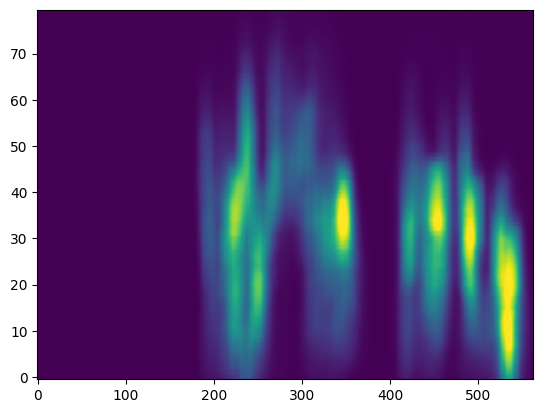

Original: angry


Explanation: angry


In [16]:
true_label, pred_label, explanation, wav_input, wav_explain = explain_audio(model, os.path.join("Audio_Speech_Actors_01-24", "Actor_21", "03-01-05-01-02-02-21.wav"))

plt.imshow(explanation.squeeze(), aspect="auto", origin="lower")
plt.show()

print(f"Original: {INTERPRETABILITY_MAP[true_label]}")
display(Audio(wav_input.squeeze().cpu().numpy(), rate=SR))

print(f"Explanation: {INTERPRETABILITY_MAP[pred_label]}")
display(Audio(wav_explain.squeeze().detach().cpu().numpy(), rate=SR))